## Data Preparation for Model Development

First, let's prepare our data. This involves checking data types, handling categorical variables, and selecting features for our models. We'll convert the 'Date' column to datetime objects and one-hot encode 'Gender' and 'Product Category' to use them in our regression models.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

print("\nDataFrame Description:")
display(df.describe())

# Convert 'Date' to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract numerical features from Date (e.g., day of the week, month)
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

# One-hot encode 'Gender' and 'Product Category'
df_encoded = pd.get_dummies(df, columns=['Gender', 'Product Category'], drop_first=True)

# Define target variable and features
# We'll use numerical features and the newly created one-hot encoded features
target = 'Total Amount'

# Features for multiple linear regression will include numerical and encoded categorical
features_mlr = ['Quantity', 'Price per Unit', 'Age', 'DayOfWeek', 'Month'] + \
               [col for col in df_encoded.columns if 'Gender_' in col or 'Product Category_' in col]

X = df_encoded[features_mlr]
y = df_encoded[target]

print("\nFeatures used for regression:", features_mlr)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

display(df_encoded.head())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   DayOfWeek         1000 non-null   int32         
 10  Month             1000 non-null   int32         
dtypes: datetime64[ns](1), int32(2), int64(5), object(3)
memory usage: 78.3+ KB

DataFrame Description:


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount,DayOfWeek,Month
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000,2.95800,6.549000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000,0.00000,1.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000,1.00000,4.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000,3.00000,6.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000,5.00000,10.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000,6.00000,12.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632,2.02097,3.452755



Features used for regression: ['Quantity', 'Price per Unit', 'Age', 'DayOfWeek', 'Month', 'Gender_Male', 'Product Category_Clothing', 'Product Category_Electronics']
Shape of X: (1000, 8)
Shape of y: (1000,)


,Transaction ID,Date,Customer ID,Age,Quantity,Price per Unit,Total Amount,DayOfWeek,Month,Gender_Male,Product Category_Clothing,Product Category_Electronics
0,1,2023-11-24,CUST001,34,3,50,150,4,11,True,False,False
1,2,2023-02-27,CUST002,26,2,500,1000,0,2,False,True,False
2,3,2023-01-13,CUST003,50,1,30,30,4,1,True,False,True
3,4,2023-05-21,CUST004,37,1,500,500,6,5,True,True,False
4,5,2023-05-06,CUST005,30,2,50,100,5,5,True,False,False


## 1. Linear Regression and Multiple Linear Regression

We will perform two types of linear regression: a simple linear regression using a single feature, and multiple linear regression using several features, including one-hot encoded categorical variables.

In [23]:
# Simple Linear Regression: Using 'Quantity' to predict 'Total Amount'

X_slr = df_encoded[['Quantity']]
y_slr = df_encoded['Total Amount']

X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(X_slr, y_slr, test_size=0.2, random_state=42)

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

y_pred_slr = slr_model.predict(X_test_slr)

r2_slr = r2_score(y_test_slr, y_pred_slr)
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
mae_slr = mean_absolute_error(y_test_slr, y_pred_slr)
rmse_slr = np.sqrt(mse_slr)

print("--- Simple Linear Regression (Quantity vs. Total Amount) ---")
print(f"R-squared: {r2_slr:.4f}")
print(f"Mean Squared Error (MSE): {mse_slr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_slr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_slr:.4f}")
print(f"Coefficients: {slr_model.coef_[0]:.2f}")
print(f"Intercept: {slr_model.intercept_:.2f}")


# Multiple Linear Regression: Using all selected features

X_mlr = X # Already defined X with all selected features
y_mlr = y # Already defined y as 'Total Amount'

X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(X_mlr, y_mlr, test_size=0.2, random_state=42)

mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

y_pred_mlr = mlr_model.predict(X_test_mlr)

r2_mlr = r2_score(y_test_mlr, y_pred_mlr)
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
mae_mlr = mean_absolute_error(y_test_mlr, y_pred_mlr)
rmse_mlr = np.sqrt(mse_mlr)

print("\n--- Multiple Linear Regression ---")
print(f"R-squared: {r2_mlr:.4f}")
print(f"Mean Squared Error (MSE): {mse_mlr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_mlr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_mlr:.4f}")
print("Coefficients:")
for feature, coef in zip(X_mlr.columns, mlr_model.coef_):
    print(f"  {feature}: {coef:.2f}")
print(f"Intercept: {mlr_model.intercept_:.2f}")

--- Simple Linear Regression (Quantity vs. Total Amount) ---
R-squared: 0.0742
Mean Squared Error (MSE): 271022.7708
Mean Absolute Error (MAE): 444.4331
Root Mean Squared Error (RMSE): 520.5985
Coefficients: 196.12
Intercept: -36.72

--- Multiple Linear Regression ---
R-squared: 0.8553
Mean Squared Error (MSE): 42349.0660
Mean Absolute Error (MAE): 173.7034
Root Mean Squared Error (RMSE): 205.7889
Coefficients:
  Quantity: 179.15
  Price per Unit: 2.49
  Age: -0.89
  DayOfWeek: -4.81
  Month: 2.29
  Gender_Male: 11.69
  Product Category_Clothing: -3.52
  Product Category_Electronics: 3.72
Intercept: -406.80


## 2. Model Evaluation Using Visualization

Visualizations help us understand the performance of our models. We'll plot actual vs. predicted values and residuals for the Multiple Linear Regression model.

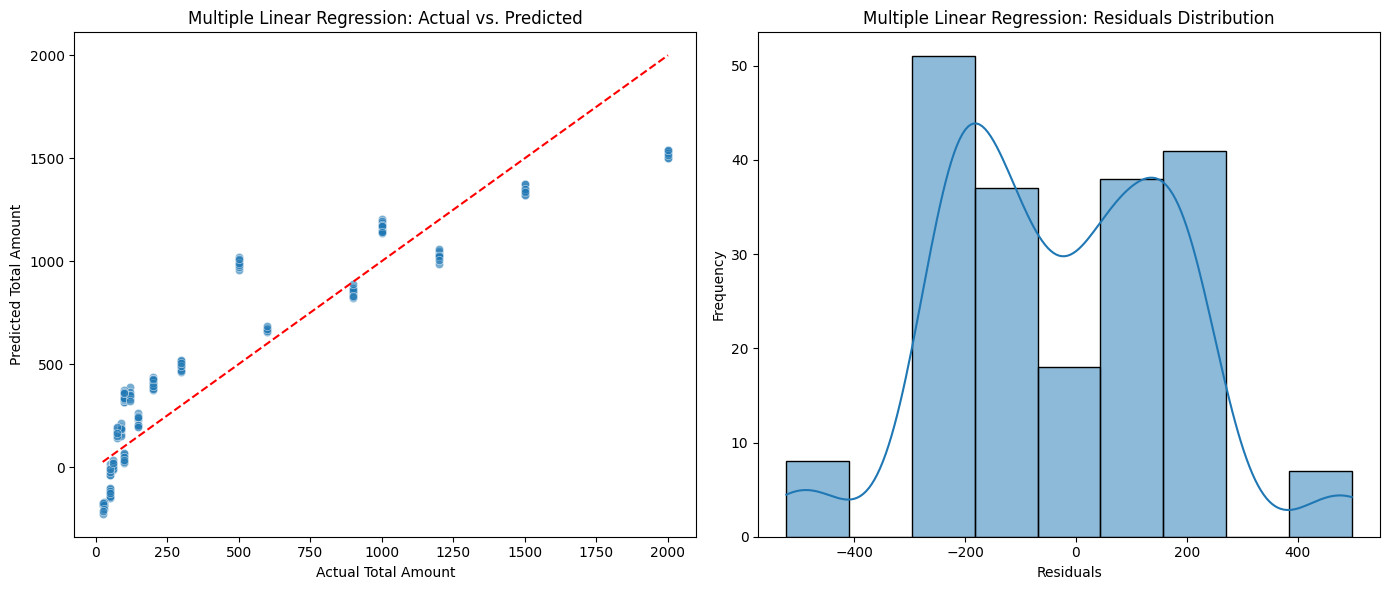

In [24]:
plt.figure(figsize=(14, 6))

# Plot Actual vs. Predicted Values for MLR
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_mlr, y=y_pred_mlr, alpha=0.6)
plt.plot([y_test_mlr.min(), y_test_mlr.max()], [y_test_mlr.min(), y_test_mlr.max()], 'r--')
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Multiple Linear Regression: Actual vs. Predicted")

# Plot Residuals for MLR
residuals = y_test_mlr - y_pred_mlr
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Multiple Linear Regression: Residuals Distribution")

plt.tight_layout()
plt.show()

## 3. Polynomial Regression and Pipeline

Polynomial regression allows us to model non-linear relationships. We'll use a `Pipeline` to combine `PolynomialFeatures` with `LinearRegression`.

--- Polynomial Regression (Degree 2, Quantity vs. Total Amount) ---
R-squared: 0.0717
Mean Squared Error (MSE): 271742.1815
Mean Absolute Error (MAE): 444.8550
Root Mean Squared Error (RMSE): 521.2890


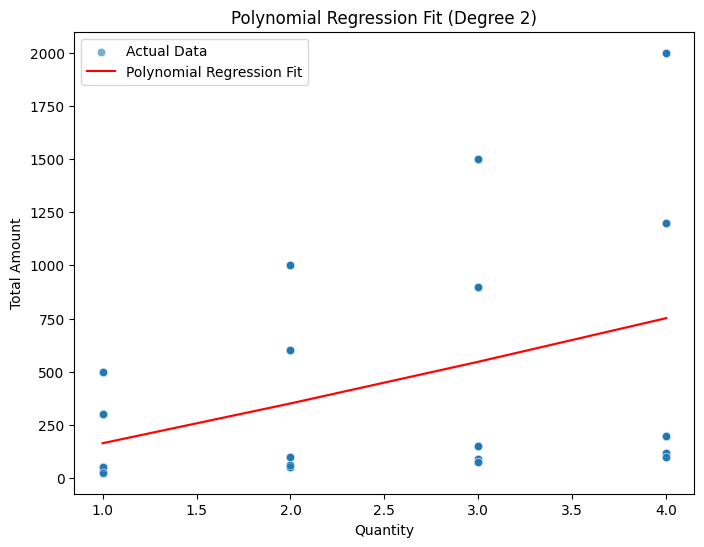

In [25]:
# Polynomial Regression using 'Quantity' as a single feature for simplicity
# We'll use a degree 2 polynomial

X_poly = df_encoded[['Quantity']]
y_poly = df_encoded['Total Amount']

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

polynomial_regressor = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_regression', LinearRegression())
])

polynomial_regressor.fit(X_train_poly, y_train_poly)

y_pred_poly = polynomial_regressor.predict(X_test_poly)

r2_poly = r2_score(y_test_poly, y_pred_poly)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
mae_poly = mean_absolute_error(y_test_poly, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print("--- Polynomial Regression (Degree 2, Quantity vs. Total Amount) ---")
print(f"R-squared: {r2_poly:.4f}")
print(f"Mean Squared Error (MSE): {mse_poly:.4f}")
print(f"Mean Absolute Error (MAE): {mae_poly:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.4f}")

# Optional: Visualize Polynomial Regression fit
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_poly['Quantity'], y=y_test_poly, label='Actual Data', alpha=0.6)
sns.lineplot(x=X_test_poly['Quantity'], y=y_pred_poly, color='red', label='Polynomial Regression Fit')
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.title("Polynomial Regression Fit (Degree 2)")
plt.legend()
plt.show()

## 4. Measures for In-sample Evaluation

Here's a summary of the key evaluation metrics for each model. These metrics help us compare the performance of different regression models.

In [26]:
evaluation_results = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression', 'Polynomial Regression (Degree 2)'],
    'R-squared': [r2_slr, r2_mlr, r2_poly],
    'MSE': [mse_slr, mse_mlr, mse_poly],
    'MAE': [mae_slr, mae_mlr, mae_poly],
    'RMSE': [rmse_slr, rmse_mlr, rmse_poly]
})

display(evaluation_results.round(4))

print("\nInterpretation of Metrics:")
print("- **R-squared**: Proportion of variance in the dependent variable that can be predicted from the independent variable(s). Higher is better (closer to 1). ")
print("- **Mean Squared Error (MSE)**: Average of the squared differences between predicted and actual values. Lower is better (closer to 0). Penalizes larger errors more.")
print("- **Mean Absolute Error (MAE)**: Average of the absolute differences between predicted and actual values. Lower is better (closer to 0). Less sensitive to outliers than MSE.")
print("- **Root Mean Squared Error (RMSE)**: Square root of MSE. Interpretable in the same units as the target variable. Lower is better (closer to 0).")

,Model,R-squared,MSE,MAE,RMSE
0,Simple Linear Regression,0.0742,271022.7708,444.4331,520.5985
1,Multiple Linear Regression,0.8553,42349.0660,173.7034,205.7889
2,Polynomial Regression (Degree 2),0.0717,271742.1815,444.8550,521.2890



Interpretation of Metrics:
- **R-squared**: Proportion of variance in the dependent variable that can be predicted from the independent variable(s). Higher is better (closer to 1). 
- **Mean Squared Error (MSE)**: Average of the squared differences between predicted and actual values. Lower is better (closer to 0). Penalizes larger errors more.
- **Mean Absolute Error (MAE)**: Average of the absolute differences between predicted and actual values. Lower is better (closer to 0). Less sensitive to outliers than MSE.
- **Root Mean Squared Error (RMSE)**: Square root of MSE. Interpretable in the same units as the target variable. Lower is better (closer to 0).


## 5. Prediction and Decision Making

Once a model is trained and evaluated, it can be used to make predictions on new, unseen data. The insights gained from model evaluation help in decision-making.

In [27]:
# Example of making a prediction with the Multiple Linear Regression model

# Let's create a hypothetical new customer transaction
# The features must match the training features: Quantity, Price per Unit, Age, DayOfWeek, Month, Gender_Male, Product Category_Electronics, Product Category_Footwear, Product Category_Home Decor

# Create a dictionary for a new data point
new_data_dict = {
    'Quantity': [5],
    'Price per Unit': [80],
    'Age': [28],
    'DayOfWeek': [3], # Thursday
    'Month': [7], # July
    'Gender_Male': [0], # Female
    'Product Category_Electronics': [0],
    'Product Category_Footwear': [0],
    'Product Category_Home Decor': [0],
    'Product Category_Books': [0],
    'Product Category_Cosmetics': [0],
    'Product Category_Sports': [0],
    'Product Category_Clothing': [1] # Clothing
}

# Ensure all features used in MLR training are present, initialize with zeros and then update
new_data_df = pd.DataFrame(0, index=[0], columns=features_mlr)
for col, val in new_data_dict.items():
    if col in new_data_df.columns:
        new_data_df[col] = val[0]


predicted_amount = mlr_model.predict(new_data_df)

print("--- Example Prediction with Multiple Linear Regression ---")
print(f"For a new transaction with features:\n{new_data_df.iloc[0].to_dict()}")
print(f"The predicted Total Amount is: ${predicted_amount[0]:.2f}")

--- Example Prediction with Multiple Linear Regression ---
For a new transaction with features:
{'Quantity': 5, 'Price per Unit': 80, 'Age': 28, 'DayOfWeek': 3, 'Month': 7, 'Gender_Male': 0, 'Product Category_Clothing': 1, 'Product Category_Electronics': 0}
The predicted Total Amount is: $661.33


### Decision Making based on Model Performance:

*   **Model Selection**: Based on the evaluation metrics, the Multiple Linear Regression model appears to perform better (higher R-squared, lower MSE/MAE/RMSE) than the Simple Linear Regression. Polynomial Regression with 'Quantity' also shows improvement over simple linear. The choice of the 'best' model depends on the problem context and the trade-off between complexity and performance.
*   **Feature Importance**: The coefficients in the linear models give an indication of how much each feature contributes to the `Total Amount`. For instance, `Price per Unit` and `Quantity` will likely have significant positive coefficients.
*   **Business Insights**: If the model accurately predicts sales, businesses can use it for:
    *   **Inventory Management**: Forecast demand for different product categories.
    *   **Pricing Strategies**: Understand the impact of price changes on total sales.
    *   **Marketing Campaigns**: Target specific demographics (e.g., age, gender) based on their purchasing patterns.
    *   **Resource Allocation**: Allocate resources more efficiently by predicting busy periods (e.g., month, day of week).